
# ☕ LCF Espresso Oracle — v2

**Machine:** DeLonghi La Specialista Arte (9-bar pump, PID-controlled boiler, conical burr grinder, manual tamp)



In [85]:

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist



## 1. Experimental Data

Columns: `Mahlgrad` (grinder dial position, ordinal), `Mahlmenge` (dose, g),
`Stamp` (tamp: 0 = light/none, 1 = firm), `pressure` (bar), `t` (extraction
time, s), `m` (yield / output mass, g), and three sensory scores
(`crema`, `acidity`, `body`, each 1–5, your own tasting notes).

**Assumption A1 (stated, not hidden):** `id` = chronological brew order.
Everything in Sections 5–6 that treats the data as a trajectory depends on
A1.


In [86]:

INITIAL_DATA = pd.DataFrame([
    [1, 1, 10, 0,  9,    22.6, 31, 2, 2, 2],
    [2, 1, 20, 1, 10.5,  48.9, 27, 4, 1, 3],
    [3, 4, 10, 0,  7,    20.25, 33, 1, 3, 1],
    [4, 2, 16.5,1, 10.75,33.1,  34, 4, 1, 4],
    [5, 2, 16.5,1, 10,   33.39, 66, 4, 1, 4],
], columns=[
    "id","Mahlgrad","Mahlmenge","Stamp",
    "pressure","t","m",
    "crema","acidity","body"
])
INITIAL_DATA


,id,Mahlgrad,Mahlmenge,Stamp,pressure,t,m,crema,acidity,body
0,1,1,10.0,0,9.00,22.60,31,2,2,2
1,2,1,20.0,1,10.50,48.90,27,4,1,3
2,3,4,10.0,0,7.00,20.25,33,1,3,1
3,4,2,16.5,1,10.75,33.10,34,4,1,4
4,5,2,16.5,1,10.00,33.39,66,4,1,4



## 2. Buckingham Π Theorem, done properly

### 2.1 Physical variables and their dimensions

We treat the *continuous, physically dimensioned* controls and outcomes as:

| symbol | meaning | dimension |
|---|---|---|
| $P$ | pump pressure | $M L^{-1} T^{-2}$ |
| $m_d$ | dose mass (`Mahlmenge`) | $M$ |
| $m_o$ | output mass (`m`) | $M$ |
| $t$ | extraction time | $T$ |
| $d$ | effective particle size implied by grinder dial (`Mahlgrad`) | $L$ |

**Assumption A2:** the grinder dial maps monotonically (not necessarily
linearly) onto particle diameter (Following a center limit theorem for n particles our median is monotonically decreasing), and we treat the dial reading itself as a
length dimensioned proxy. This is a modelling convention, not a measured
fact the La Specialista Arte's dial has no published μm calibration, so
`d` should be read as "grind coarseness index with assumed length
dimension," not literal micrometres.

`Stamp` is **excluded from the dimensional matrix on purpose.** It is a
binary regime label (tamped / not tamped), not a continuum physical
quantity there is no unit in which "0.37 of a tamp" is meaningful. It is
carried as a categorical stratifying variable instead (see plots below).

With 5 variables and 3 base dimensions $(M, L, T)$, Buckingham's theorem
says: **if the dimensional matrix has rank 3, there are exactly 5 − 3 = 2
independent dimensionless groups.**

### 2.2 Dimensional matrix and its null space

Rows = dimensions $(M,L,T)$, columns = $(P, m_d, m_o, t, d)$:


In [87]:

# columns: P, m_dose, m_out, t, d
Dmat = sp.Matrix([
    [ 1, 1, 1, 0, 0],   # M
    [-1, 0, 0, 0, 1],   # L
    [-2, 0, 0, 1, 0],   # T
])
rank = Dmat.rank()
nullspace = Dmat.nullspace()

print("rank(D) =", rank, " -> expected Pi groups =", Dmat.shape[1] - rank)
for v in nullspace:
    print(v.T)


rank(D) = 3  -> expected Pi groups = 2
Matrix([[0, -1, 1, 0, 0]])
Matrix([[1, -1, 0, 2, 1]])



The null space gives the exponent vectors $(e_P, e_{m_d}, e_{m_o}, e_t,
e_d)$ of every valid Π-group, by construction (each satisfies
$D \mathbf{e} = 0$, i.e. dimensionally consistent):

$$
\Pi_1 = \frac{m_o}{m_d} \qquad\text{(brew ratio a real, standard espresso quantity)}
$$

$$
\Pi_2 = \frac{P\, t^2\, d}{m_d} \qquad\text{(a flow/pressure number dimensionally valid)}
$$

$\Pi_1$ is exactly the industry-standard **brew ratio**, which is a good
sanity check that the dimensional analysis recovered something real rather
than an artifact. $\Pi_2$ has no standard name; treat it as an *exploratory*
grouping of pressure, time and grind coarseness, not an established
espresso metric its physical interpretation (something like a diffusive
Péclet-type number for the puck).


In [88]:

def encode_pi(df):
    '''
    Genuine Buckingham-Pi groups (see Section 2), plus Stamp carried
    separately as a categorical label (NOT part of the continuous Pi space).
    Returns (Pi, stamp) so callers can't silently mix a dimensionless
    manifold with a binary regime switch.
    '''
    m_d = df["Mahlmenge"].values
    m_o = df["m"].values
    P   = df["pressure"].values
    t   = df["t"].values
    d   = df["Mahlgrad"].values

    pi1 = m_o / m_d                 # brew ratio
    pi2 = (P * t**2 * d) / m_d      # flow/pressure number

    Pi = np.column_stack([pi1, pi2])
    stamp = df["Stamp"].values
    return Pi, stamp


def reward(df):
    '''
    Subjective taste score. The weights (2.0, 1.2, 0.8) and target values
    (acidity->2.0, body->3.0) are YOUR value judgments about ideal taste,
    encoded by hand -- not fit to data, not derived from anything physical.
    Change them to match your own palate; there is nothing to "solve" here.
    '''
    return (
        2.0 * df["crema"]
        - 1.2 * (df["acidity"] - 2.0)**2
        - 0.8 * (df["body"] - 3.0)**2
    ).values



## 3. Taste Profiles in Π-Space

Two views:

- **Π-plane**: brew ratio ($\Pi_1$) vs. flow number ($\Pi_2$), point colour
  = reward, point marker = tamp regime. This is the correct 2-D manifold to
  look for structure in, because both axes are dimensionless and therefore
  comparable across shots regardless of absolute dose/pressure/time.
- **Taste triangle**: crema / acidity / body as a radar per shot, so you can
  see *which* sensory axis is driving a high or low reward, rather than just
  the scalar reward.


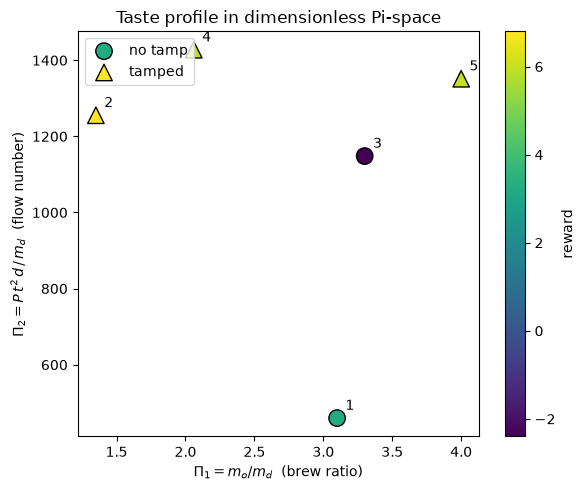

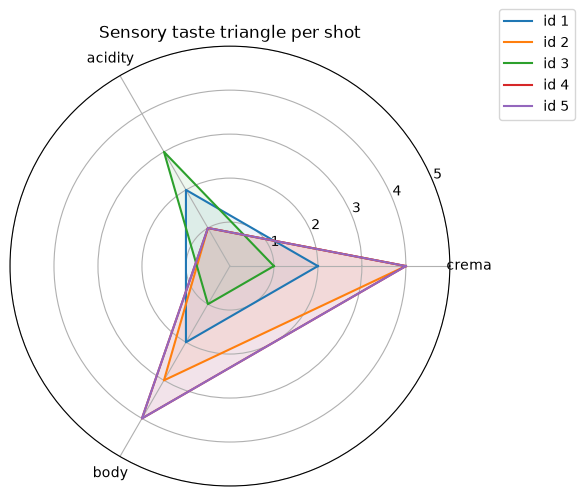

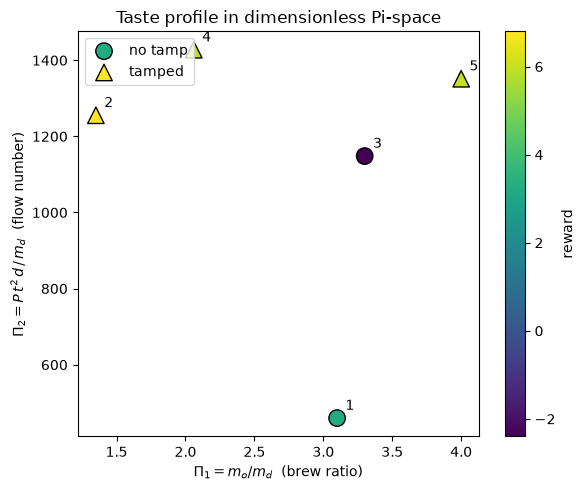

In [89]:

def plot_pi_plane(df):
    Pi, stamp = encode_pi(df)
    R = reward(df)

    fig, ax = plt.subplots(figsize=(6,5))
    for s, marker, label in [(0,'o','no tamp'), (1,'^','tamped')]:
        mask = stamp == s
        if mask.sum() == 0:
            continue
        sc = ax.scatter(Pi[mask,0], Pi[mask,1], c=R[mask], cmap="viridis",
                         marker=marker, s=140, edgecolor='k', label=label,
                         vmin=R.min(), vmax=R.max())
    for i in range(len(df)):
        ax.annotate(str(df['id'].iloc[i]), (Pi[i,0], Pi[i,1]),
                    textcoords="offset points", xytext=(6,6))
    ax.set_xlabel(r"$\Pi_1 = m_o/m_d$  (brew ratio)")
    ax.set_ylabel(r"$\Pi_2 = P\,t^2\,d\,/\,m_d$  (flow number)")
    ax.set_title("Taste profile in dimensionless Pi-space")
    ax.legend()
    plt.colorbar(sc, ax=ax, label="reward")
    plt.tight_layout()
    plt.show()


def plot_taste_radar(df):
    labels = ["crema", "acidity", "body"]
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    for _, row in df.iterrows():
        vals = [row["crema"], row["acidity"], row["body"]]
        vals += vals[:1]
        ax.plot(angles, vals, label=f"id {int(row['id'])}")
        ax.fill(angles, vals, alpha=0.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0,5)
    ax.set_title("Sensory taste triangle per shot")
    ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
    plt.tight_layout()
    plt.show()
def plot_pi_score(df):
    Pi, stamp = encode_pi(df)
    R = reward(df)

    fig, ax = plt.subplots(figsize=(6,5))
    for s, marker, label in [(0,'o','no tamp'), (1,'^','tamped')]:
        mask = stamp == s
        if mask.sum() == 0:
            continue
        sc = ax.scatter(Pi[mask,0], Pi[mask,1], c=R[mask], cmap="viridis",
                         marker=marker, s=140, edgecolor='k', label=label,
                         vmin=R.min(), vmax=R.max())
    for i in range(len(df)):
        ax.annotate(str(df['id'].iloc[i]), (Pi[i,0], Pi[i,1]),
                    textcoords="offset points", xytext=(6,6))
    ax.set_xlabel(r"$\Pi_1 = m_o/m_d$  (brew ratio)")
    ax.set_ylabel(r"$\Pi_2 = P\,t^2\,d\,/\,m_d$  (flow number)")
    ax.set_title("Taste profile in dimensionless Pi-space")
    ax.legend()
    plt.colorbar(sc, ax=ax, label="reward")
    plt.tight_layout()
    plt.show()
plot_pi_plane(INITIAL_DATA)
plot_taste_radar(INITIAL_DATA)
plot_pi_score(INITIAL_DATA)



## 4. Causal Structure of the Brewing Process

### 4.1 The mechanism, stated as a DAG

The previous "causal cone" was symmetric k-nearest-neighbours in Π-space
that is a similarity relation, not a cause → effect relation (it has no
arrows). Here is the actual mechanism, based on how the machine works:

```
Mahlgrad (grind) ──┐
Mahlmenge (dose)  ─┼──► flow resistance of the puck
Stamp (tamp)      ──┘            │
                                  ▼
pressure (set by pump/PID) ──► t (extraction time) ──► m (yield)
                                  │                       │
                                  └──────────┬────────────┘
                                             ▼
                              crema, acidity, body (sensory outcome)
```

Grind, dose and tamp are **exogenous controls** you set before the shot.
Pressure is machine-set (roughly exogenous, modulo PID variation). Time and
yield are *caused* by the controls acting through
the puck's flow resistance. Crema/acidity/body are the terminal subjectively graded outcomes by me,
caused by the whole upstream chain, not by any single variable in
isolation.

### 4.2 What this buys you that k-NN does not

Given this DAG, "what influenced shot $i$" is answered by **graph
ancestry**, not geometric distance: the ancestors of `crema/acidity/body`
for shot $i$ are exactly {`Mahlgrad`, `Mahlmenge`, `Stamp`, `pressure`,
`t`, `m`} *for that shot*.

### 4.3 Honest limits of causal claims here

With $n=5$ and no interventional (randomized) design grind, dose, tamp
and pressure were all changed together across shots the *coefficients* of
this DAG are **not identifiable** from this data (classic confounding by
simultaneous variation). We tried to reduce the confounding by designing an orthogonal array but some Issues inhibited proper testing (together with measurement errors in time and the used kitchen scale).
What follows is the graph structure and a
descriptive path decomposition of the *observed* variance, not a fitted
causal effect. Do not read the numbers in 4.4 as "if I increase pressure by
1 bar, crema increases by X".

In [90]:

import itertools

CAUSAL_EDGES = [
    ("Mahlgrad", "t"), ("Mahlgrad", "m"),
    ("Mahlmenge", "t"), ("Mahlmenge", "m"),
    ("Stamp", "t"), ("Stamp", "m"),
    ("pressure", "t"), ("pressure", "m"),
    ("t", "crema"), ("t", "acidity"), ("t", "body"),
    ("m", "crema"), ("m", "acidity"), ("m", "body"),
]

def ancestors(node, edges):
    parents = {p for p, n in edges if n == node}
    result = set(parents)
    for p in parents:
        result |= ancestors(p, edges)
    return result

for outcome in ["crema","acidity","body"]:
    print(outcome, "<-", sorted(ancestors(outcome, CAUSAL_EDGES)))


crema <- ['Mahlgrad', 'Mahlmenge', 'Stamp', 'm', 'pressure', 't']
acidity <- ['Mahlgrad', 'Mahlmenge', 'Stamp', 'm', 'pressure', 't']
body <- ['Mahlgrad', 'Mahlmenge', 'Stamp', 'm', 'pressure', 't']


In [91]:

def path_correlation_table(df, edges):
    '''
    Descriptive only (see 4.3): for each edge, report the raw correlation
    between the two variables across the 5 logged shots. This is NOT a
    causal effect estimate -- it is uncontrolled for the confounds noted
    above. Reported explicitly as "corr", never as "effect".
    '''
    rows = []
    for a,b in edges:
        va, vb = df[a].values.astype(float), df[b].values.astype(float)
        if np.std(va)==0 or np.std(vb)==0:
            corr = np.nan
        else:
            corr = np.corrcoef(va, vb)[0,1]
        rows.append((a,b,corr))
    return pd.DataFrame(rows, columns=["from","to","corr (descriptive only)"])

path_correlation_table(INITIAL_DATA, CAUSAL_EDGES)


,from,to,corr (descriptive only)
0,Mahlgrad,t,-0.557918
1,Mahlgrad,m,0.103549
2,Mahlmenge,t,0.960475
3,Mahlmenge,m,0.147960
4,Stamp,t,0.822814
5,Stamp,m,0.358892
6,pressure,t,0.765537
7,pressure,m,0.146072
8,t,crema,0.815000
9,t,acidity,-0.784760



## 5. Π-Space Coherence Geometry




In [92]:

class GeometryMemory:
    def __init__(self, Pi, R):
        self.Pi = Pi
        self.R = R

    def weights(self, sigma=None):
        D = cdist(self.Pi, self.Pi)
        if sigma is None:
            # median heuristic bandwidth -- data-driven, not a magic number
            offdiag = D[~np.eye(len(D), dtype=bool)]
            sigma = np.median(offdiag) + 1e-9
        W = np.exp(-(D**2)/(2*sigma**2))
        np.fill_diagonal(W, 0)
        return W / (W.sum(axis=1, keepdims=True) + 1e-12)


class CoherenceOracle:
    '''Renamed from Oracle: computes reward-weighted diffusion flow over
    the similarity graph in Pi-space. This is a geometric coherence
    statement, not a causal one'''
    def __init__(self, mem):
        self.m = mem

    def flow(self):
        W = self.m.weights()
        R = self.m.R.reshape(-1, 1)
        return (W @ (self.m.Pi * R)) - (self.m.Pi * R)

    def basin(self):
        W = self.m.weights()
        return self.m.Pi[np.argmax(W.sum(axis=1) * self.m.R)]

    def most_incoherent(self):
        W = self.m.weights()
        return self.m.Pi[np.argmax(np.linalg.norm(W @ self.m.Pi - self.m.Pi, axis=1))]


Pi, stamp = encode_pi(INITIAL_DATA)
R = reward(INITIAL_DATA)
mem = GeometryMemory(Pi, R)
oracle = CoherenceOracle(mem)
print("reward-weighted basin (Pi coords):", oracle.basin())
print("most incoherent shot (Pi coords):", oracle.most_incoherent())


reward-weighted basin (Pi coords): [   1.35    1255.38525]
most incoherent shot (Pi coords): [  3.1   459.684]



## 6. Trajectory Diagnostics



In [93]:

def lyapunov_proxy(Pi):
    '''Mean log step size along the trajectory. Only meaningful under A1.'''
    dX = np.linalg.norm(Pi[1:] - Pi[:-1], axis=1)
    return np.mean(np.log(dX + 1e-12))

def pispace_entropy(Pi):
    '''Structural disorder of the point cloud (order independent, always valid).'''
    D = cdist(Pi, Pi)
    P = np.exp(-D)
    P = P / P.sum()
    return -np.sum(P * np.log(P + 1e-12))

print("Lyapunov proxy (assumes A1):", lyapunov_proxy(Pi))
print("Pi-space entropy (order independent):", pispace_entropy(Pi))


Lyapunov proxy (assumes A1): 5.330258746077193
Pi-space entropy (order independent): 1.6094379124291003



## 7. Synthetic Testbed (NOT real coffee)

The block below fabricates shots from a hand-written `latent_quality`
formula. It exists to unit-test whether the coherence-geometry machinery in
Section 5 behaves sensibly (converges toward a basin, flags incoherent
points) under a **known ground truth**, before you trust it on your 5 real,
noisy, confounded shots.


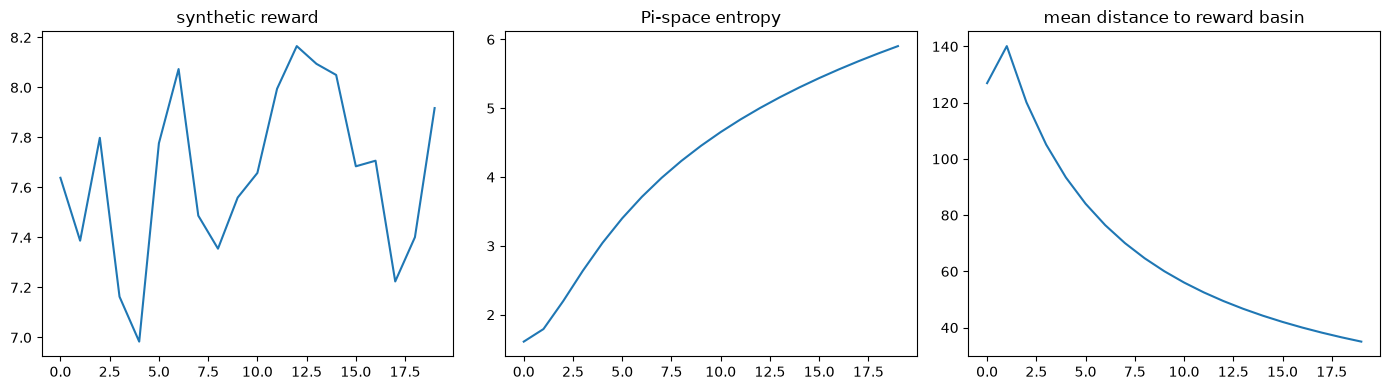

Synthetic test complete


In [94]:

def simulate_synthetic_shot(params, rng):
    g, dose, s, p, t, m_out = params
    pi_pressure = p / (m_out + 1e-6)
    pi_time = t / (m_out + 1e-6)
    latent_quality = (
        1.2*np.sin(pi_pressure) + 0.8*np.cos(pi_time) + 0.3*g - 0.2*s
    )
    crema   = np.clip(2.5 + latent_quality + rng.normal(0,0.2), 1, 5)
    acidity = np.clip(2.5 - 0.5*latent_quality + rng.normal(0,0.2), 1, 5)
    body    = np.clip(2.5 + 0.3*latent_quality + rng.normal(0,0.2), 1, 5)
    return pd.DataFrame([[rng.integers(0,9999), g, dose, s, p, t, m_out,
                           crema, acidity, body, True]],
                         columns=list(INITIAL_DATA.columns) + ["is_synthetic"])


def synthetic_convergence_test(df, steps=20, lr=0.05, seed=0):
    rng = np.random.default_rng(seed)
    df = df.copy()
    df["is_synthetic"] = False
    history = []
    for i in range(steps):
        Pi, stamp = encode_pi(df)
        R = reward(df)
        mem = GeometryMemory(Pi, R)
        oracle = CoherenceOracle(mem)
        basin = oracle.basin()
        mean = Pi.mean(axis=0)

        params = df.iloc[:, 1:7].mean(axis=0).values
        new = simulate_synthetic_shot(params, rng)
        df = pd.concat([df, new], ignore_index=True)

        history.append({
            "reward": reward(new).item(),
            "entropy": pispace_entropy(Pi),
            "dist_to_basin": np.linalg.norm(mean - basin),
        })
    return df, history

df_test, hist_test = synthetic_convergence_test(INITIAL_DATA)

fig, axes = plt.subplots(1,3, figsize=(14,4))
axes[0].plot([h["reward"] for h in hist_test]); axes[0].set_title("synthetic reward")
axes[1].plot([h["entropy"] for h in hist_test]); axes[1].set_title("Pi-space entropy")
axes[2].plot([h["dist_to_basin"] for h in hist_test]); axes[2].set_title("mean distance to reward basin")
plt.tight_layout()
plt.show()
print("Synthetic test complete")


## 8. Where to go next
 
1. **Get an interventional design.** Hold dose and tamp fixed for a session,
   sweep only pressure etc
2. **Log brew order explicitly** (timestamp, not just `id`) so Assumption A1
   in Section 6 stops being an assumption.
3. **Calibrate the grind dial** (Assumption A2), not possible without scientific equipment or setting up budget versions at home. 
